# STEP 5: Non-Linear Benchmarking (XGBoost) & SHAP Interpretability
### SpaceFund Realty (SFR) Aerospace Ratings Engine — Capstone Project

**Owner:** Ornella Meffovoung Ngnitedem (R)  —  Sikiru Mustapha (I)

---
**Pipeline position:** `... → Regularization → XGBoost & SHAP`
Reads the same `train_no_outliers.csv`, `val_clean.csv`, `test_clean.csv` as Step 4, plus `ridge_lasso_model.json` for the final comparison.

## 5.1 — Mount Drive & Rebuild Design Matrices


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings("ignore")

PROJECT_FOLDER = "/content/drive/MyDrive/Gamma_Group_1"

train = pd.read_csv(f"{PROJECT_FOLDER}/train_no_outliers.csv")
val = pd.read_csv(f"{PROJECT_FOLDER}/val_clean.csv")
test = pd.read_csv(f"{PROJECT_FOLDER}/test_clean.csv")

continuous_cols = ["Payload (kg)", "Launch Cost ($M)", "Price ($/kg)", "Funding_num"]
train_skew = train[continuous_cols].skew()
log_decision = {col: abs(train_skew[col]) > 1 for col in continuous_cols}

def build_design_matrix(df, reference_dummy_cols=None, reference_multihot_cols=None):
    df = df.copy()
    for col, do_log in log_decision.items():
        if do_log:
            df[f"log_{col}"] = np.log1p(df[col])
    log_cols = [f"log_{c}" for c, flag in log_decision.items() if flag]
    dummies = pd.get_dummies(df[["Country_Grouped", "Funding_Type"]], drop_first=True, dtype=int)
    if reference_dummy_cols is not None:
        dummies = dummies.reindex(columns=reference_dummy_cols, fill_value=0)
    multihot_cols = reference_multihot_cols or [c for c in df.columns if c.startswith(("LC_", "OA_", "TT_"))]
    X = pd.concat([df[log_cols], dummies, df[multihot_cols], df[["Funding_Missing"]]], axis=1).astype(float)
    return X, (dummies.columns.tolist() if reference_dummy_cols is None else reference_dummy_cols), multihot_cols

X_train, dummy_ref_cols, multihot_ref_cols = build_design_matrix(train)
X_val, _, _ = build_design_matrix(val, dummy_ref_cols, multihot_ref_cols)
X_test, _, _ = build_design_matrix(test, dummy_ref_cols, multihot_ref_cols)

y_train = train["SFR"].astype(float).values
y_val = val["SFR"].astype(float).values
y_test = test["SFR"].astype(float).values

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print("Note: XGBoost uses the FULL feature set -- tree models are naturally robust to multicollinearity, so VIF pruning (needed for OLS) is not required here.")

Mounted at /content/drive
Train: (140, 24), Val: (18, 24), Test: (10, 24)
Note: XGBoost uses the FULL feature set -- tree models are naturally robust to multicollinearity, so VIF pruning (needed for OLS) is not required here.


## 5.2 — Hyperparameter Search on the Validation Set


In [2]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

param_grid = {
    "max_depth": [2, 3, 4],
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.03, 0.05, 0.1],
}

search_results = []
for max_depth in param_grid["max_depth"]:
    for n_estimators in param_grid["n_estimators"]:
        for lr in param_grid["learning_rate"]:
            model = xgb.XGBRegressor(
                max_depth=max_depth, n_estimators=n_estimators, learning_rate=lr,
                random_state=42, verbosity=0,
            )
            model.fit(X_train, y_train)
            pred = model.predict(X_val)
            rmse = mean_squared_error(y_val, pred) ** 0.5
            r2 = r2_score(y_val, pred)
            search_results.append({
                "max_depth": max_depth, "n_estimators": n_estimators, "learning_rate": lr,
                "val_rmse": rmse, "val_r2": r2,
            })

search_df = pd.DataFrame(search_results).sort_values("val_rmse").reset_index(drop=True)
print("Top 5 hyperparameter combinations by validation RMSE:")
print(search_df.head(5).to_string(index=False))

best_params = search_df.iloc[0][["max_depth", "n_estimators", "learning_rate"]].to_dict()
best_params["max_depth"] = int(best_params["max_depth"])
best_params["n_estimators"] = int(best_params["n_estimators"])
print(f"\nBest hyperparameters: {best_params}")

Top 5 hyperparameter combinations by validation RMSE:
 max_depth  n_estimators  learning_rate  val_rmse   val_r2
         2           200           0.05  1.533721 0.627859
         2           200           0.10  1.546825 0.621473
         2           100           0.10  1.550856 0.619497
         2           200           0.03  1.592236 0.598921
         2            50           0.10  1.594285 0.597888

Best hyperparameters: {'max_depth': 2, 'n_estimators': 200, 'learning_rate': 0.05}


## 5.3 — Visualize the Search: Validation RMSE by Tree Depth


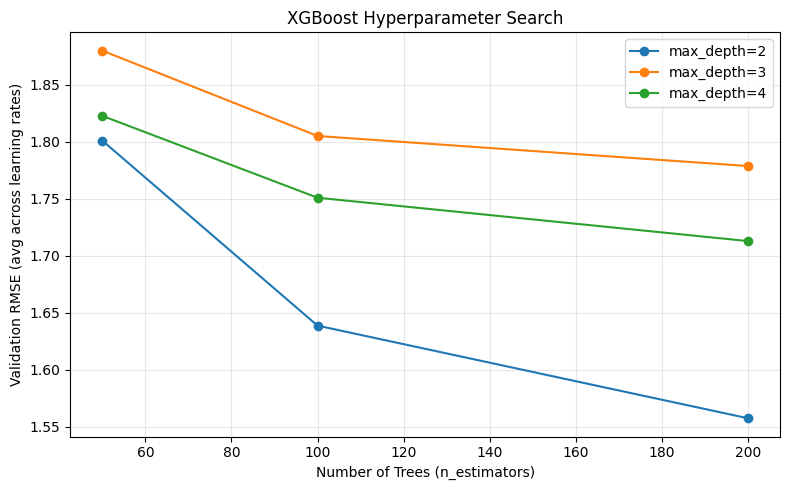

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
for depth in param_grid["max_depth"]:
    subset = search_df[search_df["max_depth"] == depth].sort_values("n_estimators")
    avg_by_trees = subset.groupby("n_estimators")["val_rmse"].mean()
    ax.plot(avg_by_trees.index, avg_by_trees.values, marker="o", label=f"max_depth={depth}")

ax.set_xlabel("Number of Trees (n_estimators)")
ax.set_ylabel("Validation RMSE (avg across learning rates)")
ax.set_title("XGBoost Hyperparameter Search")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PROJECT_FOLDER}/step5_hyperparameter_search.png", dpi=150)
plt.show()

## 5.4 — Final Fit & Test Set Evaluation


In [4]:
X_trainval = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_trainval = np.concatenate([y_train, y_val])

final_xgb = xgb.XGBRegressor(**best_params, random_state=42, verbosity=0)
final_xgb.fit(X_trainval, y_trainval)

test_pred_xgb = final_xgb.predict(X_test)
test_rmse_xgb = mean_squared_error(y_test, test_pred_xgb) ** 0.5
test_r2_xgb = r2_score(y_test, test_pred_xgb)

print(f"XGBoost TEST -> RMSE: {test_rmse_xgb:.4f}, R²: {test_r2_xgb:.4f}")

XGBoost TEST -> RMSE: 1.8557, R²: 0.3378


## 5.5 — Head-to-Head: XGBoost vs. Ridge/Lasso


     model  test_r2  test_rmse
Ridge-Full 0.502296   1.608745
   XGBoost 0.337775   1.855686


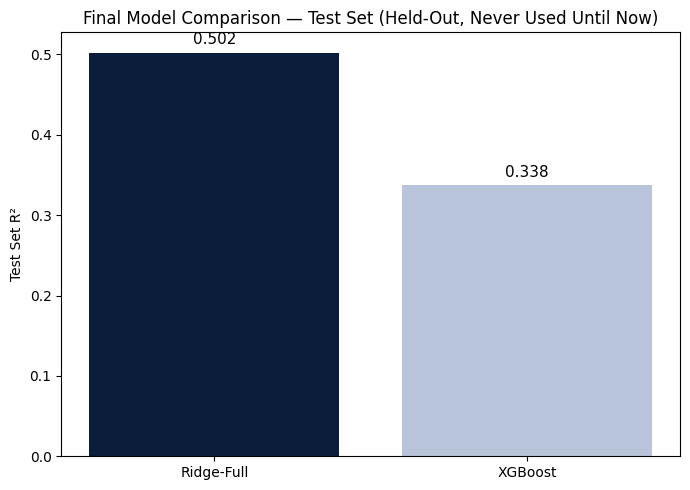


Final recommended model: Ridge-Full


In [5]:
with open(f"{PROJECT_FOLDER}/ridge_lasso_model.json") as f:
    ridge_lasso_artifact = json.load(f)

comparison = pd.DataFrame([
    {"model": ridge_lasso_artifact["model_name"], "test_r2": ridge_lasso_artifact["test_r2"], "test_rmse": ridge_lasso_artifact["test_rmse"]},
    {"model": "XGBoost", "test_r2": test_r2_xgb, "test_rmse": test_rmse_xgb},
]).sort_values("test_r2", ascending=False).reset_index(drop=True)

print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
bar_colors = ["#0B1D3A" if i == 0 else "#B7C4D9" for i in range(len(comparison))]
bars = ax.bar(comparison["model"], comparison["test_r2"], color=bar_colors)
ax.set_ylabel("Test Set R²")
ax.set_title("Final Model Comparison — Test Set (Held-Out, Never Used Until Now)")
for bar, val in zip(bars, comparison["test_r2"]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}", ha="center", fontsize=11)
plt.tight_layout()
plt.savefig(f"{PROJECT_FOLDER}/step5_final_model_comparison.png", dpi=150)
plt.show()

winner = comparison.iloc[0]["model"]
print(f"\nFinal recommended model: {winner}")

## 5.6 — SHAP Interpretability


In [6]:
import shap

explainer = shap.TreeExplainer(final_xgb)
shap_values = explainer.shap_values(X_trainval)

mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    "feature": X_trainval.columns,
    "mean_abs_shap": mean_abs_shap,
}).sort_values("mean_abs_shap", ascending=False)

print("Top 10 features by mean absolute SHAP value:")
print(shap_importance.head(10).to_string(index=False))

Top 10 features by mean absolute SHAP value:
                      feature  mean_abs_shap
         Funding_Type_Unknown       1.050019
                OA_Suborbital       0.437491
              log_Funding_num       0.382159
         log_Launch Cost ($M)       0.258297
                     LC_Small       0.207312
          Funding_Type_Public       0.154230
             log_Payload (kg)       0.139975
Country_Grouped_United States       0.134019
                TT_Spaceplane       0.046772
             log_Price ($/kg)       0.041319


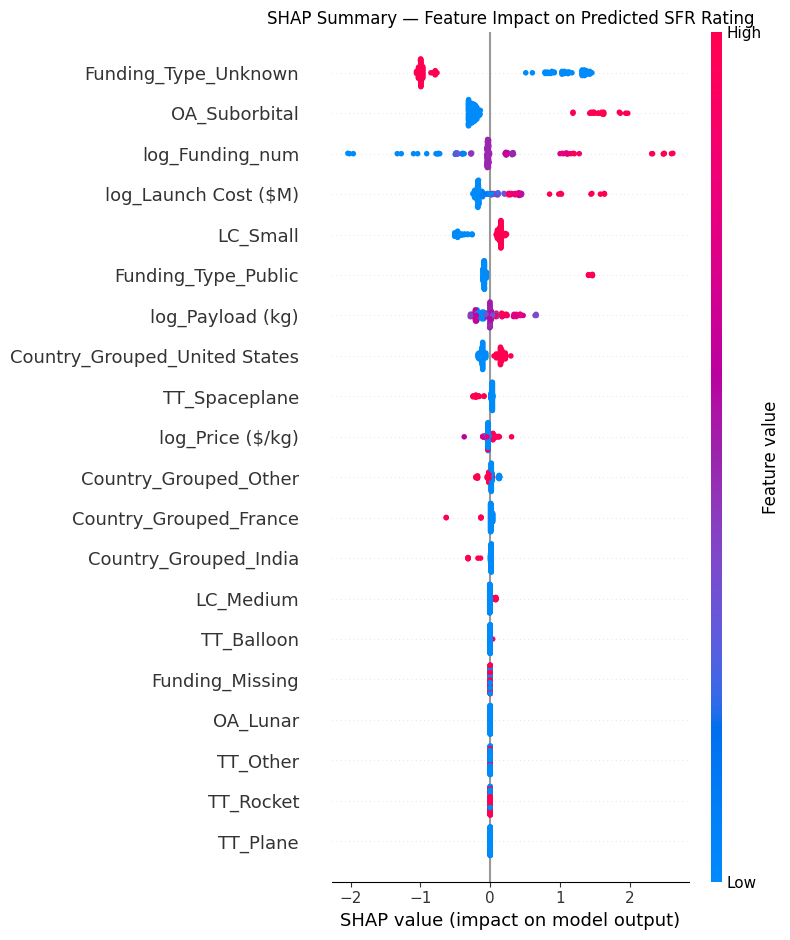

In [7]:
# SHAP summary (beeswarm) plot -- shows both importance AND the direction of each
# feature's effect (red = high value pushes prediction up, blue = low value pushes it down)
fig = plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values, X_trainval, show=False)
plt.title("SHAP Summary — Feature Impact on Predicted SFR Rating")
plt.tight_layout()
plt.savefig(f"{PROJECT_FOLDER}/step5_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## 5.7 — Compare SHAP Importance to Ridge Coefficients


In [8]:
ridge_coef_df = pd.DataFrame({
    "feature": ridge_lasso_artifact["feature_names"],
    "ridge_abs_coef": np.abs(ridge_lasso_artifact["coefficients"]),
}).sort_values("ridge_abs_coef", ascending=False)

top_shap = set(shap_importance.head(8)["feature"])
top_ridge = set(ridge_coef_df.head(8)["feature"])
overlap = top_shap & top_ridge

print(f"Top 8 features by SHAP: {sorted(top_shap)}")
print(f"Top 8 features by Ridge coefficient: {sorted(top_ridge)}")
print(f"\nOverlap: {len(overlap)} of 8 features agree between the two models: {sorted(overlap)}")

Top 8 features by SHAP: ['Country_Grouped_United States', 'Funding_Type_Public', 'Funding_Type_Unknown', 'LC_Small', 'OA_Suborbital', 'log_Funding_num', 'log_Launch Cost ($M)', 'log_Payload (kg)']
Top 8 features by Ridge coefficient: ['Funding_Missing', 'Funding_Type_Public', 'Funding_Type_Unknown', 'LC_Medium', 'LC_Small', 'OA_Suborbital', 'log_Funding_num', 'log_Launch Cost ($M)']

Overlap: 6 of 8 features agree between the two models: ['Funding_Type_Public', 'Funding_Type_Unknown', 'LC_Small', 'OA_Suborbital', 'log_Funding_num', 'log_Launch Cost ($M)']


## 5.8 — Save Final Artifacts


In [9]:
final_xgb.save_model(f"{PROJECT_FOLDER}/xgboost_model.json")
shap_importance.to_csv(f"{PROJECT_FOLDER}/shap_feature_importance.csv", index=False)

final_summary = {
    "recommended_model": winner,
    "ridge_test_r2": ridge_lasso_artifact["test_r2"],
    "xgboost_test_r2": float(test_r2_xgb),
    "ridge_test_rmse": ridge_lasso_artifact["test_rmse"],
    "xgboost_test_rmse": float(test_rmse_xgb),
    "rationale": "Small training set (140 rows) favors the regularized linear model; XGBoost's added flexibility overfit rather than generalized.",
}
with open(f"{PROJECT_FOLDER}/final_model_selection.json", "w") as f:
    json.dump(final_summary, f, indent=2)

print(f"Saved to Google Drive folder: {PROJECT_FOLDER}")
print("  - xgboost_model.json")
print("  - shap_feature_importance.csv")
print("  - final_model_selection.json")
print("  - step5_hyperparameter_search.png")
print("  - step5_final_model_comparison.png")
print("  - step5_shap_summary.png")
print(f"\nStep 5 complete. Final recommended model for deployment: {winner}")

Saved to Google Drive folder: /content/drive/MyDrive/Gamma_Group_1
  - xgboost_model.json
  - shap_feature_importance.csv
  - final_model_selection.json
  - step5_hyperparameter_search.png
  - step5_final_model_comparison.png
  - step5_shap_summary.png

Step 5 complete. Final recommended model for deployment: Ridge-Full
